# SVM Classification Project

## Projenin Amacı

Bu projede Iris veri seti kullanılarak SVM (Support Vector Machine) algoritması uygulanacaktır.

Amaç, çiçek türlerini sınıflandırmak ve SVM algoritmasının performansını incelemektir.

## Proje Yol Haritası

1. Veri setinin yüklenmesi
2. Veri setinin incelenmesi
3. Eksik veri kontrolü
4. Bağımlı ve bağımsız değişkenlerin ayrılması
5. Verilerin ölçeklendirilmesi
6. Train/Test ayrımı
7. SVM modelinin kurulması
8. Tahmin işlemleri
9. Accuracy hesaplama
10. Confusion Matrix oluşturma
11. Classification Report oluşturma
12. Sonuçların değerlendirilmesi

# Veri Setinin Yüklenmesi

Bu bölümde Iris veri seti sklearn kütüphanesi üzerinden yüklenmektedir.

In [1]:
# Iris datasetini yüklüyoruz

import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Veri Setinin İncelenmesi

Bu bölümde veri setinin yapısı, istatistiksel özellikleri ve eksik veri durumu incelenmektedir.

In [2]:
# Veri yapısını inceliyoruz

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [3]:
# Sayısal istatistikleri inceliyoruz

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Eksik veri kontrolü yapıyoruz

df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

# Bağımlı ve Bağımsız Değişkenlerin Ayrılması

Bu bölümde target sütunu ayrılmaktadır.

In [5]:
# X ve y oluşturuyoruz

X = df.drop("target", axis=1)

y = df["target"]

# Train Test Split ve Ölçeklendirme

Bu bölümde veri train/test olarak ayrılmakta ve standardize edilmektedir.

In [6]:
# Train test split yapıyoruz

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
# Verileri ölçeklendiriyoruz

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# SVM Modelinin Kurulması

Bu bölümde SVM algoritması kullanılmaktadır.

In [8]:
# SVM modelini kuruyoruz

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 1.0


# Model Performansının Değerlendirilmesi

Bu bölümde model performansı Confusion Matrix ve Classification Report ile değerlendirilmektedir.

In [9]:
# Confusion Matrix oluşturuyoruz

from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, svm_pred)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [10]:
# Classification Report oluşturuyoruz

from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Sonuçların Görselleştirilmesi

Bu bölümde model accuracy değeri görselleştirilmektedir.

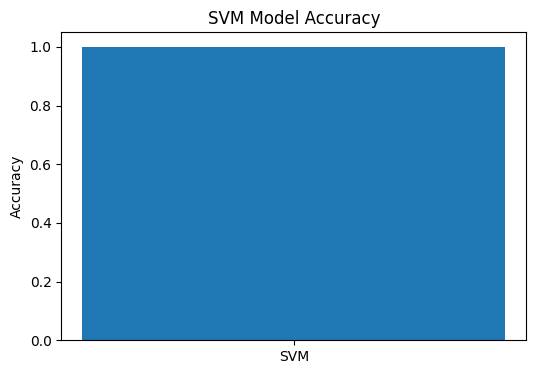

In [11]:
# Accuracy grafiği oluşturuyoruz

import matplotlib.pyplot as plt

models = ["SVM"]

scores = [svm_acc]

plt.figure(figsize=(6,4))

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("SVM Model Accuracy")

plt.show()

# SVM Classification Project Sonuçları

Bu projede Iris veri seti kullanılarak SVM algoritması uygulanmıştır.

Proje kapsamında:

- Veri analizi yapılmıştır.
- Veriler ölçeklendirilmiştir.
- Train/Test ayrımı gerçekleştirilmiştir.
- SVM modeli eğitilmiştir.

Projede:
- Support Vector Machine (SVM)

algoritması kullanılmıştır.

Ayrıca:
- Confusion Matrix
- Classification Report
- Accuracy görselleştirmesi

oluşturulmuştur.

Bu proje ile:
- Classification
- SVM
- Machine Learning
- Data Preprocessing

konuları uygulamalı olarak gerçekleştirilmiştir.